# sfig5 — K vs K Aggregation, All Main Tasks (Supplementary Fig. S-5)

Extends main paper Fig. 2 to all five main tasks.
AUROC vs inference window count K with iso-compute contours.

**Data**: `heatmap_df_test.csv` per task, Transformer head.

In [3]:
%matplotlib inline

In [4]:
import sys
from pathlib import Path

# ── Workspace root ─��──────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils (TBME style, data, panels)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, FONT_TITLE, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_analysis_all_k, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [5]:
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [6]:
# ── Config ─────────────────────────────────────────────────────────��──────────
HEAD  = "transformer"
SPLIT = "test"
TASKS = MAIN_TASKS

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print("Heatmap sizes:", {t: len(v) for t, v in hmaps.items()})

Heatmap sizes: {'sex_binary': 76, 'bmi_binary': 81, 'age_class': 81, 'sleep_efficiency_binary': 85, 'apnea_binary': 81}


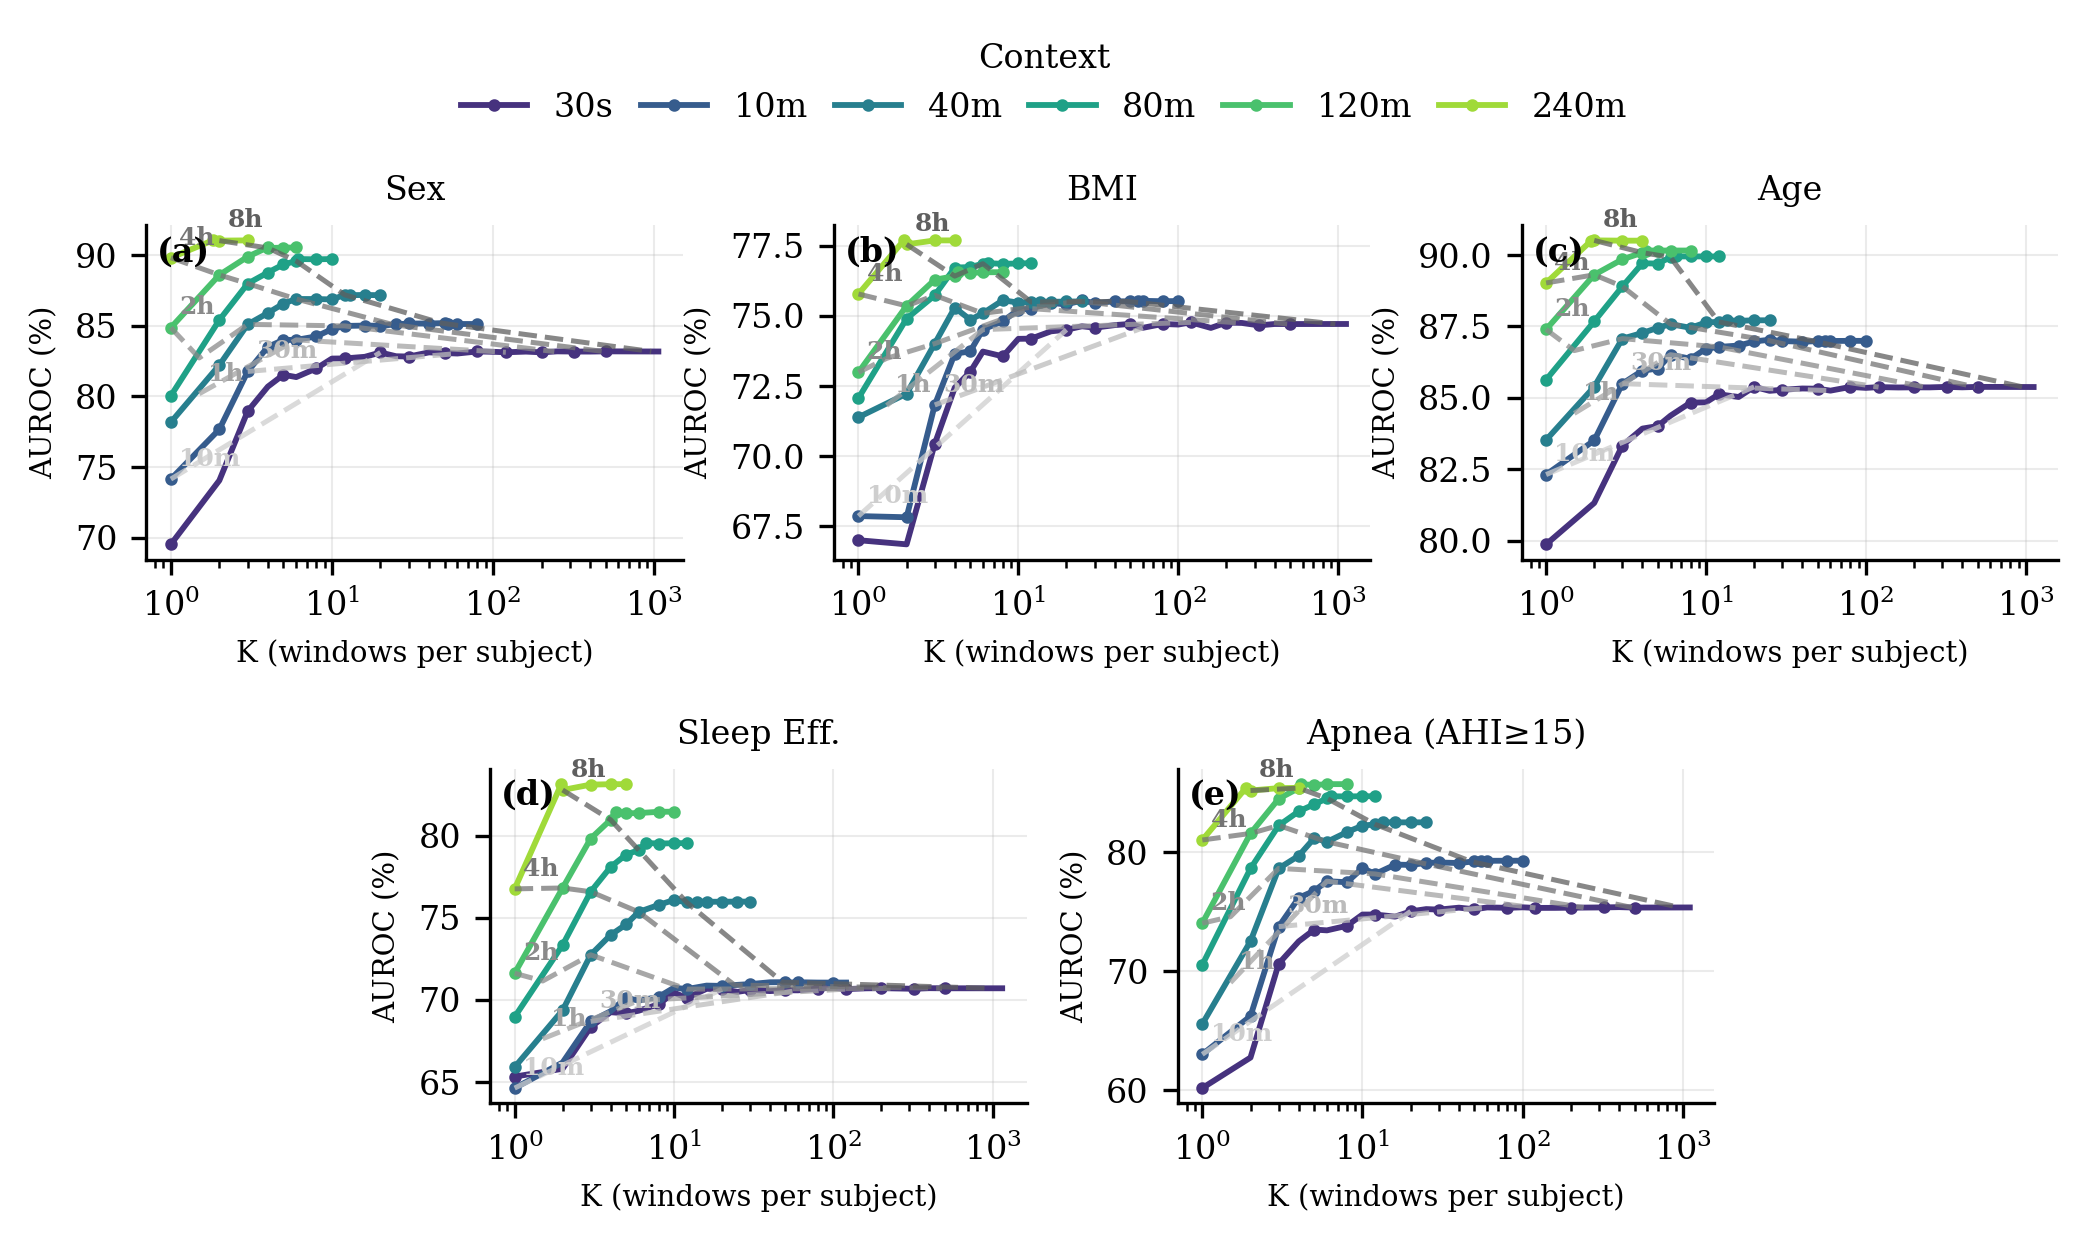

In [8]:
METRIC     = "auroc"
SUPP_NCOLS = 3
SUPP_ROW_H = 2.1
SUPP_NROWS = (len(TASKS) + SUPP_NCOLS - 1) // SUPP_NCOLS

_labels = [chr(97 + i) for i in range(len(TASKS))]
_n_last = len(TASKS) % SUPP_NCOLS or SUPP_NCOLS
_n_full = len(TASKS) // SUPP_NCOLS

_mosaic = []
for _row in range(_n_full):
    _row_labels = _labels[_row * SUPP_NCOLS : (_row + 1) * SUPP_NCOLS]
    _mosaic.append([lbl for lbl in _row_labels for _ in range(2)])
if _n_last < SUPP_NCOLS:
    _last = _labels[_n_full * SUPP_NCOLS:]
    _pad  = SUPP_NCOLS - _n_last
    _mosaic.append(['.'] * _pad +
                   [lbl for lbl in _last for _ in range(2)] +
                   ['.'] * _pad)

fig, axd = plt.subplot_mosaic(
    _mosaic, figsize=(FULL_W, SUPP_NROWS * SUPP_ROW_H)
)
for _i, (_lbl, _task) in enumerate(zip(_labels, TASKS)):
    _ax = axd[_lbl]
    panels.kvsk_panel(_ax, hmaps[_task], col=METRIC, show_legend=False)
    _ax.set_title(TASK_LABEL[_task], fontsize=FONT_TITLE)
    add_panel_label(_ax, f'({chr(97+_i)})')

_sh, _sl = axd[_labels[0]].get_legend_handles_labels()
fig.legend(_sh, _sl, title='Context', loc='upper center',
           ncol=len(_sh), fontsize=FONT_BASE, title_fontsize=FONT_BASE,
           frameon=False, bbox_to_anchor=(0.5, 0.98),
           handlelength=2.0, columnspacing=0.8)
fig.tight_layout(h_pad=1.5, w_pad=1.0, rect=[0, 0, 1, 0.88])
plt.show()

In [9]:
save_figure(fig, FINAL_OUT, "sfig5_kvsk")
import shutil
shutil.copy(FINAL_OUT / "sfig5_kvsk.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig5_kvsk.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig5_kvsk.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig3_kvsk.pdf
Saved + copied → TBME_submission/sfig3_kvsk.pdf
